# Прогнозирование заказов такси

Компания «Чётенькое такси» собрала исторические данные о заказах такси в аэропортах. Чтобы привлекать больше водителей в период пиковой нагрузки, нужно спрогнозировать количество заказов такси на следующий час. Постройте модель для такого предсказания.  

Значение метрики RMSE на тестовой выборке должно быть не больше 48.

## Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split,TimeSeriesSplit, GridSearchCV, cross_val_score
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller  
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## Загрузка данных 

In [2]:
data = pd.read_csv('taxi.csv', parse_dates=[0], index_col=[0])
data.head()

,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32


In [3]:
data.shape

(26496, 1)

## Анализ данных 

In [427]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


Размер датасета: 26496  
Количество столбцов: 1 

In [428]:
data.describe()

,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


119 - максимум, который сильное выделяется на фоне остальных значений. Проведем детальный анализ выбросов  

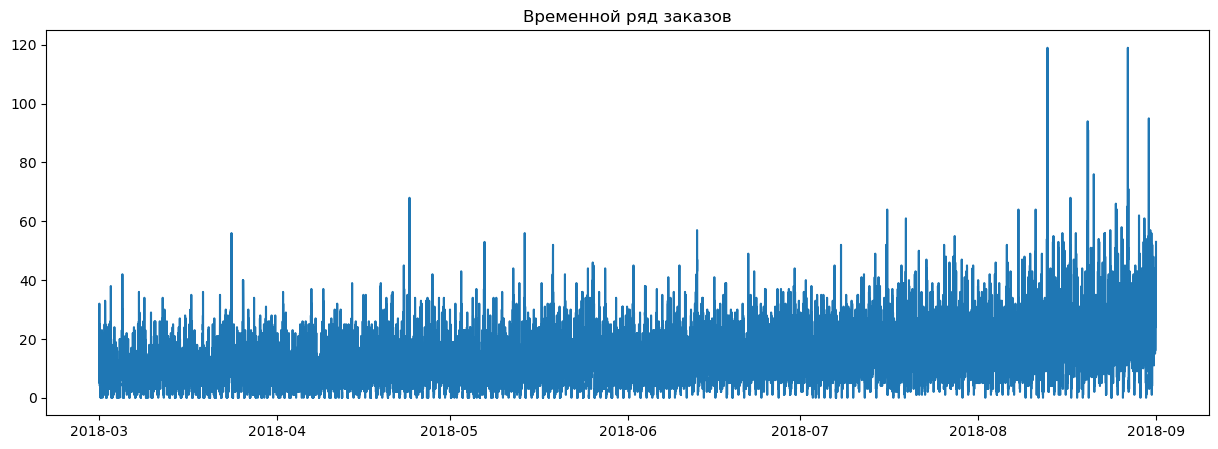

In [429]:
plt.figure(figsize=(15,5))
plt.plot(data['num_orders'])
plt.title('Временной ряд заказов')
plt.show()

График показывает явный тренд. Пики (выбросы) регулярны, распределены по всему ряду, нет одиночных аномалий.    

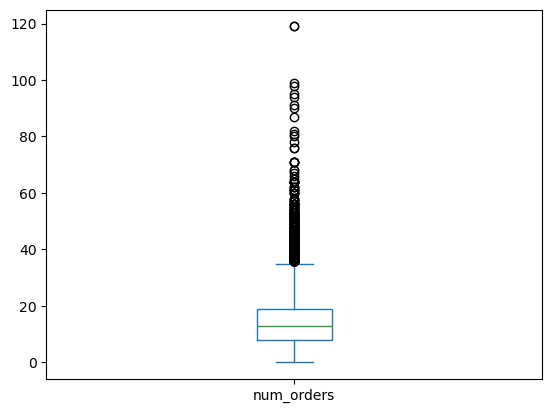

In [430]:
data['num_orders'].plot(kind='box')
plt.show()

На графике наблюдается значительное количество значений, выходящих за пределы межквартильного размаха. Однако данные значения не являются единичными и случайными, а представляют собой регулярные пики спроса.

Вывод - гипотеза о выбросах отвергается. Эти точки являются частью структуры данных, представляют собой регулярные пики спроса, усиливающиеся со временем  

In [431]:
# Проверим, отсортирован ли временной ряд
data.index.is_monotonic_increasing

True

Ряд отсортирован, можем продолжать анализ

In [432]:
# Проверим число дубликатов
if len(data.index.unique()) == len(data): print('Дубликатов нет')
else: print('Есть дубликаты')

Дубликатов нет


In [433]:
# Проверим число пропусков
print('Количество пропусков в ряде', data.isna().sum())


Количество пропусков в ряде num_orders    0
dtype: int64


In [434]:
# Соберем данные за каждый час
data = data.resample('1H').sum()

C:\Users\0brot\AppData\Local\Temp\ipykernel_36976\4226922509.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  data = data.resample('1H').sum()


In [435]:
# Проверим ряд на стационарность 
result = adfuller(data['num_orders']) 

# Распечатка результатов теста
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

if result[1] < 0.05:
    print("Нулевую гипотезу отвергаем (ряд стационарен)")
else:
    print("Нулевую гипотезу не отвергаем (ряд нестационарен)")

ADF Statistic: -3.068924289027958
p-value: 0.028940051402612743
Critical Values: {'1%': np.float64(-3.431842162413052), '5%': np.float64(-2.8621993540813637), '10%': np.float64(-2.567120978470452)}
Нулевую гипотезу отвергаем (ряд стационарен)


In [436]:
# Проверим значения данных за час  
data.describe()

,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


Наличие нулевых часов вызывает подозрение, проверим их количество

In [437]:
zero_hours = data[data['num_orders'] == 0]
print(f"Нулевых часов: {len(zero_hours)}")

Нулевых часов: 1


Всего 4 нулевых часа из 4416- это ничтожно мало, статистически незначимо, продолжим анализ 

#### Промежуточный вывод по анализу данных
Данные не содержат пропусков и дубликатов, а также корректно отсортированы по времени, что делает их пригодными для анализа без дополнительной базовой очистки. Формально обнаруженные выбросы являются регулярными пиками спроса (например, в часы прилётов) и представляют собой часть структуры ряда, поэтому их удаление нецелесообразно.

Проверка с помощью теста Дики-Фуллера показала, что ряд стационарен (p-value < 0.05), что подтверждает отсутствие единичного корня.

Таким образом, данные качественные, сохраняют важные закономерности и могут быть напрямую использованы для построения модели прогнозирования.

### Анализ тренда и сезонности и остатков   

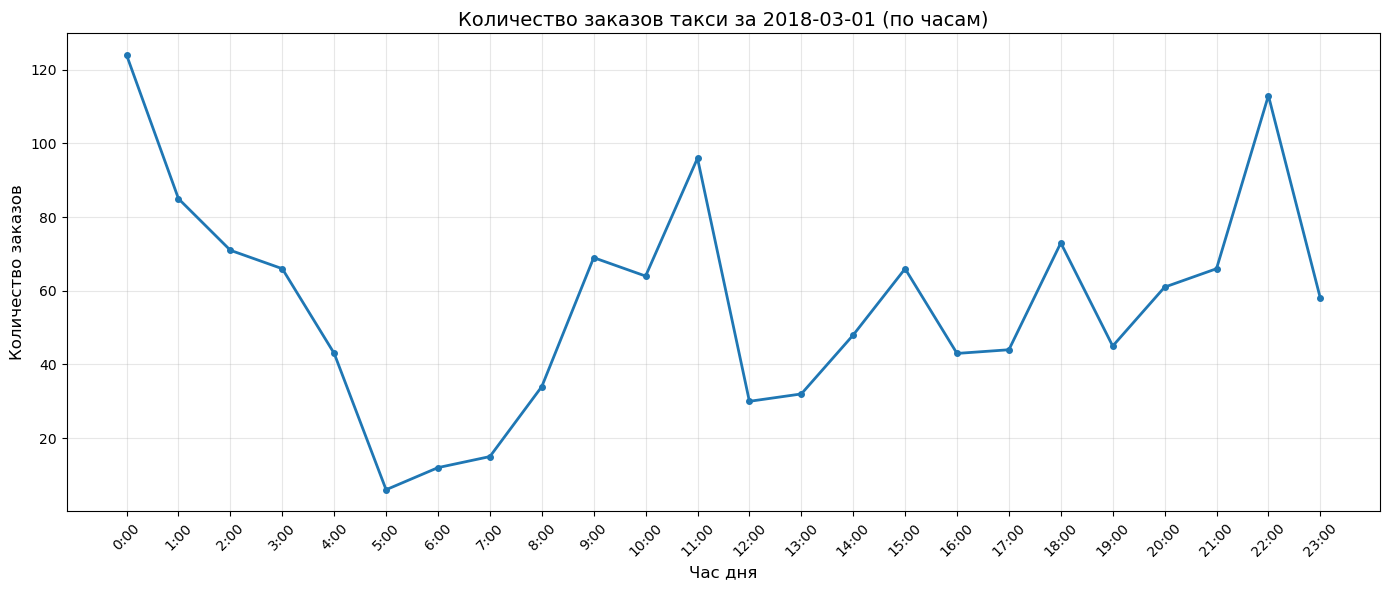

In [438]:
day_data = data['2018-03-01 00:00:00':'2018-03-01 23:59:59']

plt.figure(figsize=(14, 6))
plt.plot(day_data.index, day_data['num_orders'], marker='o', linewidth=2, markersize=4)

plt.xticks(day_data.index, [f'{h}:00' for h in range(24)], rotation=45)

plt.title('Количество заказов такси за 2018-03-01 (по часам)', fontsize=14)
plt.xlabel('Час дня', fontsize=12)
plt.ylabel('Количество заказов', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Наблюдаем три явных часовых пика: 00:00, 11:00, 22:00.

- 00:00 – главный пик (120+ заказов). Связан с ночными международными рейсами. После пика – резкий спад до 4-5 утра (меньше 20 заказов).

- 05:00-11:00 – утренний рост. Первый пик в 9:00 (~70 заказов), небольшой спад до 10:00, затем снова резкий рост, достигающий максимального дневного пика в 11:00 (~95 заказов) из-за деловых поездок и обеденных прилётов. После - резкий спад до 12 (меньше 40 заказов). 

- 12:00-16:00 – практически незаметный рост до 13:00 затем резкий рост,достигающее пика в 16:00 (> 60 заказов). После спад практически до 40 заказаов

- 16:00-18:00 – слабый рост до 17:00 затем резкое увелечение,достигающее пика в 18:00 (~ 70 заказов). После в 19:00 возвращение к  значениям 17:00 (чуть больше 40 заказов) 

- 19:00-23:00 – вечерний рост с скачками в 20:00 и 21:00, после стремительный рост до 22:00 (~ 115 заказов) – возвращение рейсов, туристы. Затем резкий спад до 23:00 (~ 70 заказов)  

Вывод: Данные демонстрируют чёткую суточную сезонность с двумя основными пиками (00:00 и 22:00) и одним второстепенным (11:00).   
Ночные пики: 00:00 и 22:00. Дневные пики: 9:00, 11:00 (самый близкий к ночным значениям), 15:00, 18:00.      

Проверим эту сезонность и выявим тренд  

,trend,seasonal,resid
datetime,,,
2018-03-02 00:00:00,54.833333,60.248112,-25.081445
2018-03-02 01:00:00,55.229167,20.177074,44.593759
2018-03-02 02:00:00,55.416667,28.982743,-9.399410
2018-03-02 03:00:00,55.187500,17.885407,-9.072907
2018-03-02 04:00:00,55.854167,2.791145,-38.645312
2018-03-02 05:00:00,57.479167,-41.563022,-4.916145
2018-03-02 06:00:00,58.625000,-59.182671,11.557671
2018-03-02 07:00:00,59.041667,-55.104461,3.062794
2018-03-02 08:00:00,59.791667,-11.212840,-2.578827


<Axes: xlabel='datetime'>

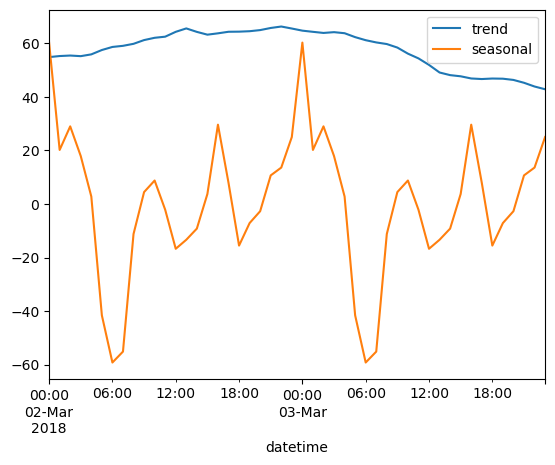

In [439]:
# Рассмотрим двухдневный период 
decomposed = seasonal_decompose(data)
decomposed_df = pd.DataFrame({'trend': decomposed.trend, 'seasonal': decomposed.seasonal, 'resid': decomposed.resid})
display(decomposed_df['2018-03-02':'2018-03-03'])
decomposed_df.loc['2018-03-02':'2018-03-03', ['trend', 'seasonal']].plot()

Функция помогла подтвердить сезонность, связанную с часами.В тренде закономерности найти не удалось. Рассмотрим его на более крупных периодах: неделях и месяцах.

,trend,seasonal,resid
datetime,,,
2018-03-04,4603.125000,1.136868e-13,-13.034039
2018-03-11,9355.000000,1.989520e-13,56.000000
2018-03-18,9852.500000,1.989520e-13,-67.500000
2018-03-25,9780.520833,1.989520e-13,-13.520833
2018-04-01,9751.666667,1.989520e-13,0.333333
2018-04-08,9374.416667,1.989520e-13,2.583333
2018-04-15,10341.250000,1.989520e-13,10.750000
2018-04-22,11207.333333,1.989520e-13,16.666667
2018-04-29,12033.458333,1.989520e-13,7.541667


<Axes: xlabel='datetime'>

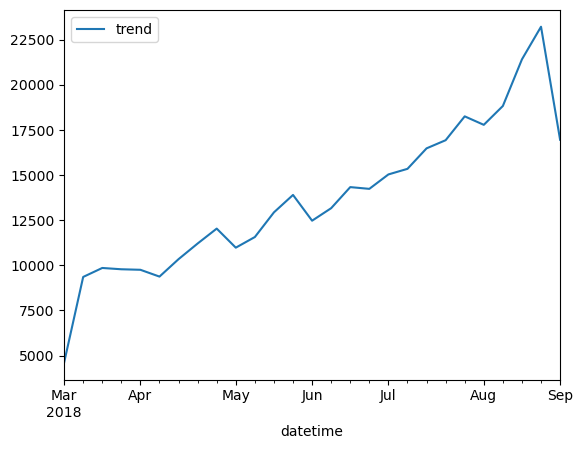

In [440]:
decomposed_week = decomposed_df.resample('1W').sum()
display(decomposed_week['2018-03-04':'2018-09-02'])
decomposed_week.loc['2018-03-04':'2018-09-02', ['trend']].plot()

С разбивкой по неделям наблюдается тренд, но не явный. Разобьем данные по месяцам  

C:\Users\0brot\AppData\Local\Temp\ipykernel_36976\2979244314.py:1: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  decomposed_month = decomposed_df.resample('1m').sum()


,trend,seasonal,resid
datetime,,,
2018-03-31,42021.687500,8.810730e-13,35.403461
2018-04-30,45965.041667,8.526513e-13,-26.041667
2018-05-31,54863.312500,8.810730e-13,-43.312500
2018-06-30,59871.916667,8.526513e-13,34.083333
2018-07-31,74459.750000,8.810730e-13,-54.750000
2018-08-31,92931.000000,8.810730e-13,18.909039


<Axes: xlabel='datetime'>

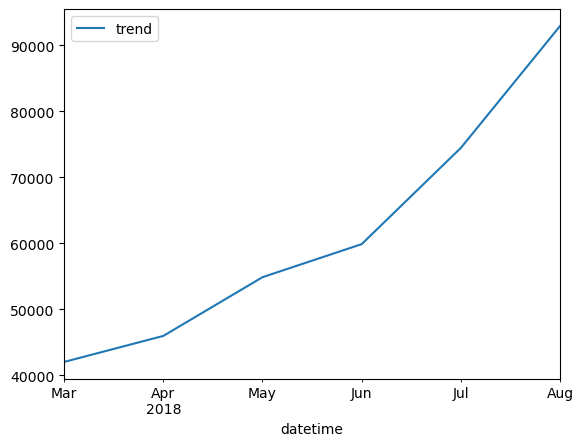

In [441]:
decomposed_month = decomposed_df.resample('1m').sum()
display(decomposed_month['2018-03-31':'2018-08-31'])
decomposed_month.loc['2018-03-31':'2018-08-31', ['trend']].plot()

В масштабе месяцев наблюдается явный восходящий тренд.  
Таким образом, в масштабе часов имеется сезонность, а в мастштабе месяцев имеется тренд.  
Следовательно месяцы и часы могут оказаться значимыми признаками для модели.  


Рассмотрим остатки 

<Axes: >

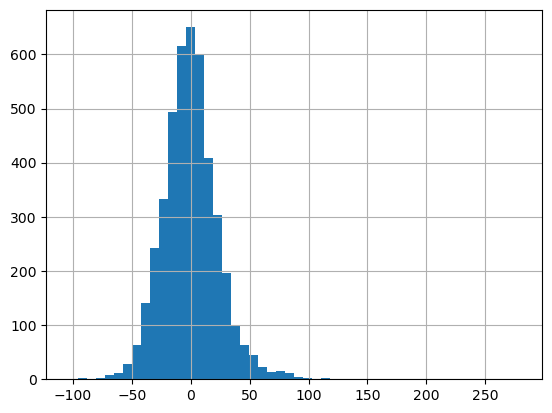

In [442]:
decomposed_df['resid'].hist(bins=50)

Гистограмма остатков показывает, что их распределение сосредоточено вокруг нуля и имеет форму, близкую к нормальному распределению. Это свидетельствует о том, что основные закономерности временного ряда успешно учтены.

При этом наблюдается наличие редких значительных отклонений (длинный правый хвост), что может быть связано с резкими всплесками спроса, обусловленными внешними факторами.

В целом остаточная компонента не содержит выраженной структуры, что подтверждает корректность выделения тренда и сезонности.

### Анализ ACF и PACF

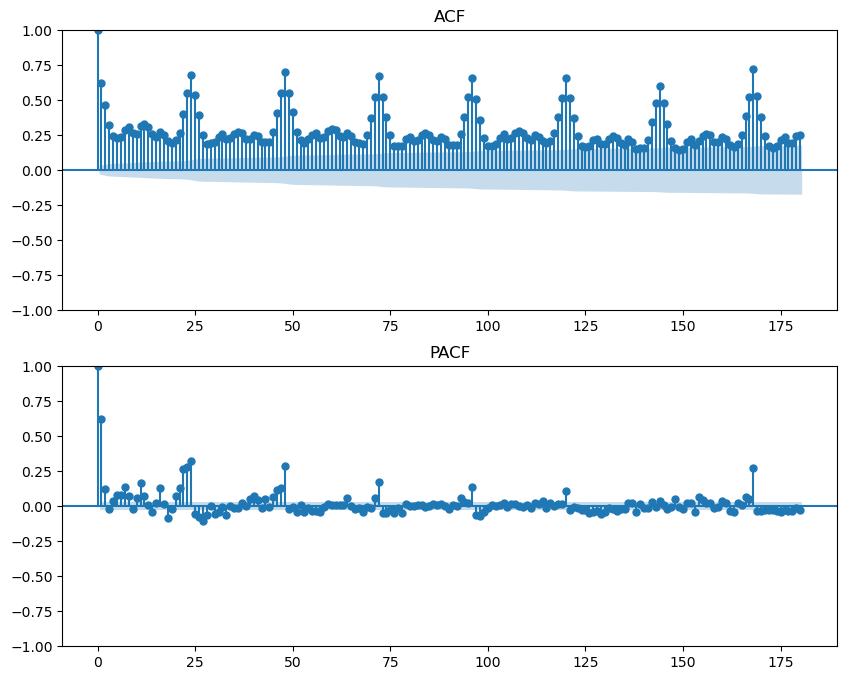

In [443]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# ACF покажет общую структуру ряда
plot_acf(data['num_orders'], ax=ax[0], lags=180, title='ACF')

# PACF покажет только прямые связи
plot_pacf(data['num_orders'], ax=ax[1], lags=180, title='PACF')

plt.show() 

Анализ ACF показывает наличие выраженных пиков на лагах, кратных 24 (24, 48, 72 и далее). Это свидетельствует о наличии сильной суточной сезонности: значения ряда существенно коррелируют с наблюдениями за предыдущие сутки и их кратные периоды. Кроме того, автокорреляция медленно убывает, что указывает на наличие тренда и зависимости между наблюдениями на длительных промежутках времени.

График PACF показывает значимый пик на лаге 1, что говорит о сильной зависимости текущего значения от предыдущего. Также наблюдаются отдельные значимые пики на лагах, кратных 24, однако они значительно слабее, чем в ACF. Это указывает на то, что основная прямая зависимость приходится на ближайшие наблюдения, тогда как более дальние лаги влияют косвенно через промежуточные значения.

### Промежуточный вывод    
  
Проведён анализ временного ряда с использованием автокорреляционных функций (ACF, PACF), а также декомпозиции на тренд, сезонность и остатки. Дополнительно исследована суточная и недельная структура данных.

Анализ ACF показал наличие выраженных пиков на лагах, кратных 24 (24, 48, 72 и т.д.), что свидетельствует о сильной суточной сезонности. Также автокорреляция убывает медленно, что указывает на наличие тренда и долгосрочной зависимости. График PACF выявил значимый пик на лаге 1, подтверждающий сильную зависимость текущего значения от предыдущего, а также менее выраженные пики на лагах, кратных 24.

Детальный анализ суточной сезонности показал наличие устойчивых повторяющихся паттернов. Наблюдаются три ключевых пика спроса: основной — в 00:00 (более 120 заказов), связанный с ночными рейсами, второй по величине — в 22:00 (около 115 заказов), а также дневной пик в 11:00 (до 95 заказов), обусловленный деловой активностью. Дополнительно выделяются менее выраженные пики в 9:00, 16:00 и 18:00.Таким образом, временной ряд демонстрирует чёткую суточную сезонность.

Анализ трендовой компоненты показывает, что временной ряд имеет восходящий характер. При этом рост происходит неравномерно: в начале периода увеличение спроса выражено слабо, однако начиная с июня наблюдается заметное ускорение тренда. Летние месяцы характеризуются наибольшими значениями количества заказов, что может быть связано с сезонным ростом активности (отпуска, туризм, увеличение пассажиропотока). Таким образом, можно говорить о наличии восходящего тренда с ускорением, начинающимся примерно с июня.

Анализ остаточной компоненты показывает, что в целом остатки распределены вокруг нуля, однако к концу временного ряда наблюдается увеличение их разброса. Это свидетельствует о росте доли труднообъяснимых значений (шума) в данных. В результате в тестовую выборку попадает больше наблюдений с высокой вариативностью, что может усложнять задачу прогнозирования для модели.

Следовательно, возможное ухудшение качества модели на тестовой выборке по сравнению с обучающей не обязательно связано с переобучением, а может объясняться увеличением нестабильности и вариативности данных в конце рассматриваемого периода.

Таким образом, временной ряд характеризуется выраженной суточной сезонностью, зависимостью от предыдущих значений и наличием долгосрочного тренда. Для моделирования целесообразно использовать лаговые признаки (в первую очередь lag_1, lag_24 и их кратные — lag_48, lag_72, lag_168), а также признаки времени (час, день недели). Добавление месяца избыточно т.к данные представлены только одним полугодием. Полученные результаты подтверждают корректность выбранных признаков и объясняют их вклад в качество прогнозирования.  


## Подготовка данных для обучения, создание новых признаков (Feature Engineering) 

Создадим дополнительные признаки для модели 

In [444]:
# Создадим признак на основе месяца

data['dayofweek'] = data.index.dayofweek
data['hour'] = data.index.hour
data = data.join(pd.get_dummies(data['hour'], drop_first=True, prefix='hour'))
data.drop('hour', axis=1, inplace=True)

In [445]:
# Создадим признаки на основе сдвига(добавим также данные за то же час, но за сутки назад, двое суток назад и т.д) 
for lag in [1, 23, 24, 48, 72, 168]:
    data[f'lag_{lag}'] = data['num_orders'].shift(lag)

In [446]:
# Создадим признак на основе скользящего среднего за сутки
data['rolling_mean'] = data['num_orders'].shift().rolling(24).mean()

<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍  по остальным признакам все логично и хорошо.

In [447]:
# Разделим данные на обучающую и тестовую выборку
train, test = train_test_split(data, shuffle=False, test_size=0.1)
print(f"Train размер: {len(train)}")
print(f"Test размер: {len(test)}")

Train размер: 3974
Test размер: 442


<div class="alert alert-success">
<h2> Комментарий ревьюера <a class="tocSkip"> </h2>

👍 Верно, ничего не перемешиваем.
</div>

In [448]:
# Удалим строки с отсутствующими данными, появившимися в результате создания признаков
train = train.dropna()
test = test.dropna()

In [449]:
# Отделим целевой показатель от признаков
features_train = train.drop('num_orders', axis=1)
target_train = train['num_orders']

features_test = test.drop('num_orders', axis=1)
target_test = test['num_orders']

Данные готовы для обучения 

## Сравнение моделей 

Проверим базовую модель

In [450]:
pred_previous = target_test.shift()
pred_previous.iloc[0] = target_train.iloc[-1]

rmse = np.sqrt(mean_squared_error(target_test, pred_previous))
print(f"Baseline RMSE (previous value): {rmse:.2f}")

Baseline RMSE (previous value): 58.86


RMSE выше требуемого, проверим другие модели: линейная регрессия, Ridge, Lasso, а также ансамблевые методы — случайный лес и градиентный бустинг.  

Выбор линейных моделей обусловлен особенностями задачи. Временной ряд обладает выраженной зависимостью от предыдущих значений (лагов) и сезонных факторов, что часто хорошо описывается линейными зависимостями. Кроме того, модели Ridge и Lasso позволяют учитывать регуляризацию, что снижает риск переобучения и, в случае Lasso, выполняет отбор наиболее значимых признаков.  

Ансамблевые методы (Random Forest и Gradient Boosting) были добавлены для сравнения, так как они способны моделировать более сложные нелинейные зависимости и учитывать взаимодействие признаков. Это позволяет проверить, есть ли в данных скрытые закономерности, которые не улавливаются линейными моделями.


In [451]:
cv = TimeSeriesSplit(n_splits=3)

# 1. Linear Regression
model_lr = LinearRegression()

score_lr = cross_val_score(
    model_lr,
    features_train,
    target_train,
    scoring='neg_mean_squared_error',
    cv=cv
)

rmse_lr = np.mean(-score_lr)**0.5

# 2. Ridge (с подбором alpha)
ridge = Ridge()

param_ridge = {
    'alpha': [0.01, 0.1, 1, 10]
}

grid_ridge = GridSearchCV(
    ridge,
    param_ridge,
    scoring='neg_mean_squared_error',
    cv=cv
)

grid_ridge.fit(features_train, target_train)

rmse_ridge = (-grid_ridge.best_score_)**0.5



# 3. Lasso (с подбором alpha)
lasso = Lasso(max_iter=10000)

param_lasso = {
    'alpha': [0.001, 0.01, 0.1, 1]
}

grid_lasso = GridSearchCV(
    lasso,
    param_lasso,
    scoring='neg_mean_squared_error',
    cv=cv
)

grid_lasso.fit(features_train, target_train)

rmse_lasso = (-grid_lasso.best_score_)**0.5


# 4. Random Forest
rf = RandomForestRegressor(random_state=42)

param_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, 15]
}

grid_rf = GridSearchCV(
    rf,
    param_rf,
    scoring='neg_mean_squared_error',
    cv=cv
)

grid_rf.fit(features_train, target_train)

rmse_rf = (-grid_rf.best_score_)**0.5


# 5. Gradient Boosting
gbr = GradientBoostingRegressor(random_state=42)

param_gbr = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_gbr = GridSearchCV(
    gbr,
    param_gbr,
    scoring='neg_mean_squared_error',
    cv=cv
)

grid_gbr.fit(features_train, target_train)

rmse_gbr = (-grid_gbr.best_score_)**0.5



print("CV RMSE:")
print(f"LR: {rmse_lr:.2f}")
print(f"Ridge: {rmse_ridge:.2f}")
print(f"Lasso: {rmse_lasso:.2f}")
print(f"RandomForest: {rmse_rf:.2f}")
print(f"GradientBoosting: {rmse_gbr:.2f}")

CV RMSE:
LR: 22.90
Ridge: 22.79
Lasso: 22.84
RandomForest: 23.95
GradientBoosting: 23.58


In [452]:
models = {
    'LinearRegression': (model_lr, rmse_lr),
    'Ridge': (grid_ridge.best_estimator_, rmse_ridge),
    'Lasso': (grid_lasso.best_estimator_, rmse_lasso),
    'RandomForest': (grid_rf.best_estimator_, rmse_rf),
    'GradientBoosting': (grid_gbr.best_estimator_, rmse_gbr)
}

best_name, (best_model, best_score) = min(models.items(), key=lambda x: x[1][1])

print(f"\nЛучшая модель: {best_name} (CV RMSE = {best_score:.2f})")


Лучшая модель: Ridge (CV RMSE = 22.79)


По результатам кросс-валидации наилучшее качество показали линейные модели. Минимальное значение RMSE было достигнуто моделью Ridge (22.79), что делает её предпочтительной среди рассмотренных вариантов.

Модель Lasso показала сопоставимый результат, однако уступила Ridge по качеству. Базовая линейная регрессия также продемонстрировала близкий результат, но без регуляризации.

Ансамблевые методы (Random Forest и Gradient Boosting) показали более высокие значения RMSE, что свидетельствует об отсутствии необходимости моделирования сложных нелинейных зависимостей в данной задаче.

Это объясняется тем, что основная структура временного ряда (суточная сезонность и зависимость от предыдущих значений) уже эффективно описывается с помощью лаговых признаков и линейных моделей.

Таким образом, в качестве финальной модели выбрана Ridge-регрессия, обеспечивающая наилучшее качество прогнозирования при умеренной сложности и устойчивости к переобучению.

## Тестирование лучшей модели 

In [453]:
# обучаем на всём train
best_model.fit(features_train, target_train)

# предсказание
pred = best_model.predict(features_test)

rmse_test = np.sqrt(mean_squared_error(target_test, pred))
print(f"Test RMSE: {rmse_test:.2f}")

Test RMSE: 34.60


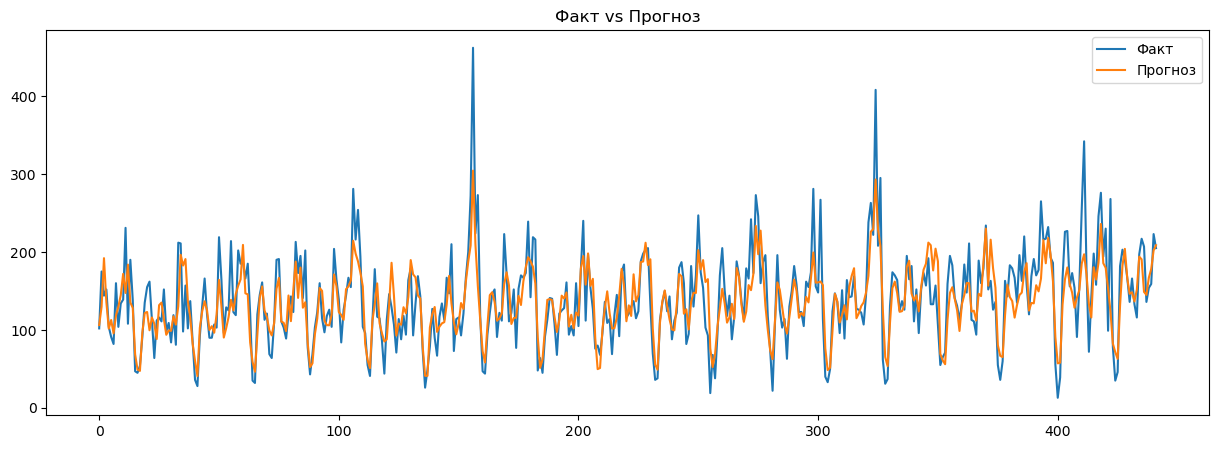

In [458]:
plt.figure(figsize=(15,5))
plt.plot(target_test.values, label='Факт')
plt.plot(pred, label='Прогноз')
plt.legend()
plt.title('Факт vs Прогноз')
plt.show()

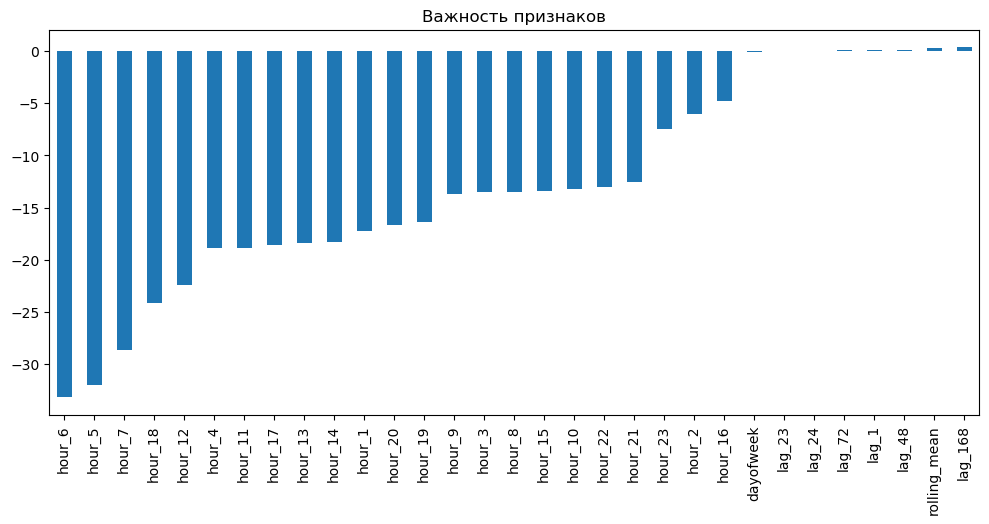

In [459]:
if hasattr(best_model, 'coef_'):
    coef = pd.Series(best_model.coef_, index=features_train.columns)
    coef.sort_values().plot(kind='bar', figsize=(12,5))
    plt.title('Важность признаков')
    plt.show()

## Вывод

Модель демонстрирует хорошее качество прогнозирования (RMSE = 34.60), что значительно ниже требуемого порога. Она успешно улавливает ключевые закономерности временного ряда, включая суточную и недельную сезонность, а также общий восходящий тренд.

Наибольший вклад в предсказание вносят лаговые признаки, особенно lag_168, lag_48 и lag_1, что подтверждает наличие сильной автокорреляции и повторяющихся паттернов. Часовые признаки также оказывают значимое влияние, отражая выраженную суточную сезонность.

Модель хорошо воспроизводит общую динамику ряда, однако сглаживает резкие пики спроса, что объясняет оставшуюся ошибку. Это связано с влиянием внешних факторов, которые не представлены в данных.

В целом модель можно считать пригодной для решения бизнес-задачи прогнозирования нагрузки и планирования привлечения водителей.